In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import explain_ensemble
# from diabnet.model import load
from diabnet.data import get_feature_names
from diabnet.ensemble import Ensemble
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
import pandas as pd
from pandas.plotting import parallel_coordinates

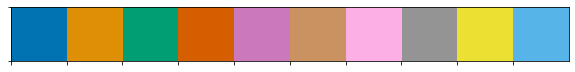

In [3]:
colors = sns.color_palette("colorblind")
sns.palplot(colors)
sns.set_style("whitegrid")
sns.set_style("ticks",{'axes.grid': True,'grid.color': '.95', 'grid.linestyle': '-'})

In [6]:
ensemble = Ensemble('../diabnet/models/model-5-soft-label-age-positives-2500-dropout0-bn-decay-flood-hyperopt-batch256-lc2')

../diabnet/models/model-5-soft-label-age-positives-2500-dropout0-bn-decay-flood-hyperopt-batch256-lc2


In [7]:
# feature names
feat_names = get_feature_names("../datasets/visits_sp_unique_test_positivo_1000_random_0.csv", BMI=False, sex=True, parents_diagnostics=True)

In [33]:
feat_names[-20:]

['snp_1_28265165',
 'snp_7_62322704',
 'snp_6_57432511',
 'snp_19_5147864',
 'snp_9_1667961',
 'snp_7_142786651',
 'snp_9_68692515',
 'snp_12_53198338',
 'snp_6_37571581',
 'snp_20_52032232',
 'snp_20_52032233',
 'snp_20_26104019',
 'snp_20_50189624',
 'snp_1_143276644',
 'snp_16_9536673',
 'snp_20_25734788',
 'AGE',
 'sex',
 'mo_t2d',
 'fa_t2d']

In [8]:
# predictor = load('../diabnet/models/model-sp-soft-label-positives-1000-decay2.pth')
# feat_names = get_feature_names("../datasets/visits_sp_unique_test_positivo_1000_random_0.csv", BMI=False, sex=True, parents_diagnostics=True)

In [9]:
e_train = explain_ensemble.ExplainModel(ensemble, feat_names, "../datasets/visits_sp_unique_train_positivo_1000_random_0.csv")

In [10]:
e_test = explain_ensemble.ExplainModel(ensemble, feat_names, "../datasets/visits_sp_unique_test_positivo_1000_random_0.csv")

In [11]:
def feat_importance(values, age, sex, samples_per_model=1):
    imp = values.calc_attr(age, sex, samples_per_model=samples_per_model)
    # testa se o SNP tem valores 1 ou 2. caso não tenha, sua importancia não pode ser calculada
    s = {k: [np.mean(imp[k]), np.median(imp[k])] for k in imp if len(imp[k]) > 0} 
    df = pd.DataFrame.from_dict(s, orient='index')
    df.rename(columns={0:f'{sex}{age}_mean', 1:f'{sex}{age}_median'}, inplace=True)
    # df.sort_values(by=0, ascending=False).head(50)
    return df
    

# Feature Importance

Qual a importância dos SNPs independentemente de outras características (sexo, diagnóstico dos pais, idade*).
*Para torna independente da idade fixamos a idade em 50.

In [12]:
age = 50
sex = 'X' # 'X' significa qualquer sexo

Não há um consenso se a análise de importância das características (feature importance) deve ser feita com os dados de teste ou treinamento. Nós testamos os dois...

In [13]:
feat_imp_train = feat_importance(e_train, 50, 'X', samples_per_model=1)
feat_imp_test = feat_importance(e_test, 50, 'X', samples_per_model=1)

No entanto, no conjunto de teste 44 dos 1000 SNPs não possuem o gene base do alelo recessivo (valores 1 ou 2) e consequentemente, não conseguimos atribuir um valor de importância. E como notamos pelo boxplot abaixo, boa parte deles podem ser importantes.

44 SNPs não tem valores no conjunto de teste


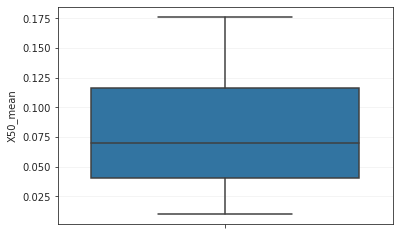

In [14]:
excluded = feat_imp_train[feat_imp_train.index.isin(feat_imp_test.index) == False]
print(f"{excluded.count()[0]} SNPs não tem valores no conjunto de teste")
sns.boxplot(y="X50_mean", data=excluded)

In [15]:
tmp = feat_imp_train.join(feat_imp_test, how='inner', lsuffix='_train', rsuffix='_test')
tmp['SNP'] = tmp.index
# parallel_coordinates(tmp, '1_M50', cols='M50_mean','F50_mean'])
tmp = tmp.sort_values(by="X50_mean_train")
tmp # apenas 956 pq 44 dos SNPs não tem valores 1 ou 2 no conjunto de teste 

,X50_mean_train,X50_median_train,X50_mean_test,X50_median_test,SNP
snp_17_15464147,-0.068235,-0.062488,-0.070281,-0.065778,snp_17_15464147
snp_16_19717582,-0.039498,-0.025211,-0.042356,-0.034744,snp_16_19717582
snp_21_11058226,-0.032946,-0.030398,-0.033310,-0.029815,snp_21_11058226
snp_16_82889990,-0.026962,-0.023770,-0.019956,-0.016110,snp_16_82889990
snp_11_89308027,-0.025994,-0.022087,-0.028485,-0.022961,snp_11_89308027
...,...,...,...,...,...
snp_18_56742728,0.204727,0.228291,0.181606,0.211270,snp_18_56742728
snp_1_209147965,0.206318,0.246766,0.259314,0.311768,snp_1_209147965
snp_11_120855337,0.237023,0.257174,0.252804,0.295397,snp_11_120855337
snp_10_15653813,0.277959,0.309476,0.296206,0.339019,snp_10_15653813


Comparando a média e a mediana da importância calculada para os conjuntos de treinamento e teste podemos ver que há uma correlação significativa (como esperado). Logo, optaremos por realizar as análises subsequentes apenas com a importância calculada no conjunto de treinamento.

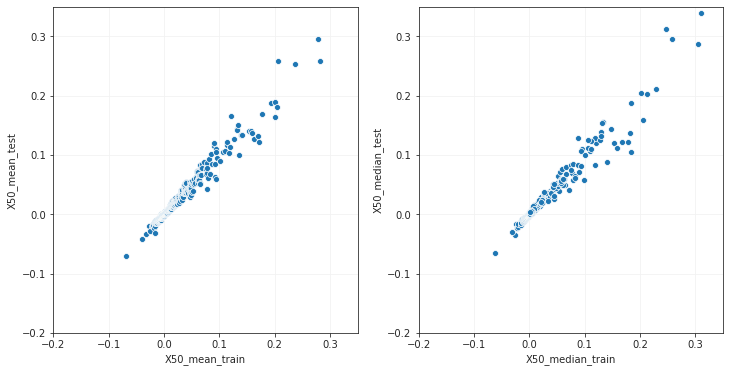

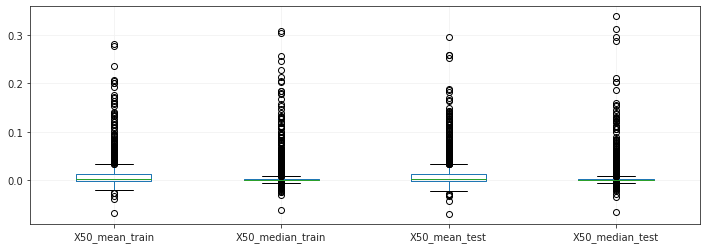

In [16]:
plt.figure(figsize=(12,6));
plt.subplot(121);
# plt.scatter(tmp.X50_mean_train.values, tmp.X50_mean_test.values);
sns.scatterplot(x="X50_mean_train", y="X50_mean_test", data=tmp)
plt.ylim(-0.2,0.35)
plt.xlim(-0.2,0.35)
plt.subplot(122);
# plt.scatter(tmp.X50_median_train.values, tmp.X50_median_test.values);
sns.scatterplot(x="X50_median_train", y="X50_median_test", data=tmp)
plt.ylim(-0.2,0.35)
plt.xlim(-0.2,0.35)
plt.figure(figsize=(12,4));
tmp.boxplot();

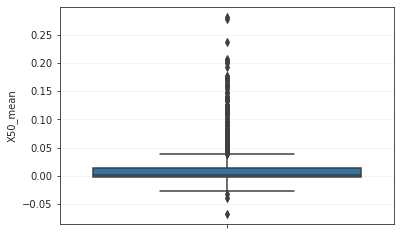

In [17]:
sns.boxplot(y="X50_mean", data=feat_imp_train)

In [18]:
feat_imp_train.describe()

,X50_mean,X50_median
count,1000.000000,1000.000000
mean,0.015080,0.012204
std,0.037248,0.037090
min,-0.068235,-0.062488
25%,-0.002106,-0.000494
50%,0.001440,0.000071
75%,0.014536,0.004037
max,0.281739,0.309476


In [19]:
feat_imp_train["chr"] = [int(s.split('_')[1]) for s in feat_imp_train.index]
feat_imp_train["pos"] = [float(s.split('_')[2]) for s in feat_imp_train.index]
feat_imp_train

,X50_mean,X50_median,chr,pos
snp_8_133462953,0.071451,0.002053,8,133462953.0
snp_2_91635413,0.003682,0.000332,2,91635413.0
snp_9_25963828,0.000365,0.000002,9,25963828.0
snp_1_17764169,0.003527,0.000781,1,17764169.0
snp_12_41767967,-0.007160,-0.003333,12,41767967.0
...,...,...,...,...
snp_20_26104019,0.003148,0.000877,20,26104019.0
snp_20_50189624,-0.006170,-0.004812,20,50189624.0
snp_1_143276644,-0.000522,0.000005,1,143276644.0
snp_16_9536673,0.001907,-0.000024,16,9536673.0


O gráfico da atribuição dos SNPs separado por cromossomo (abaixo) mostra que os chr 1 e 3 

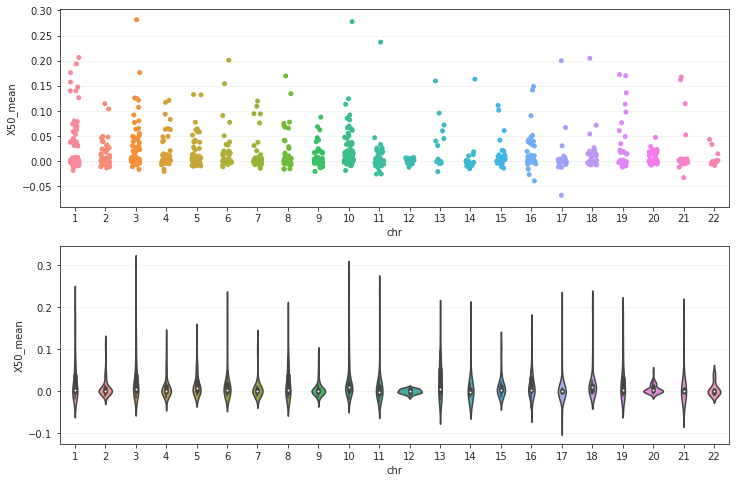

In [20]:
fig = plt.figure(figsize=(12,8))
plt.subplot(211)
sns.stripplot(x="chr", y="X50_mean", data=feat_imp_train, jitter=0.15)
plt.subplot(212)
sns.violinplot(x="chr", y="X50_mean", data=feat_imp_train, whis=np.inf)

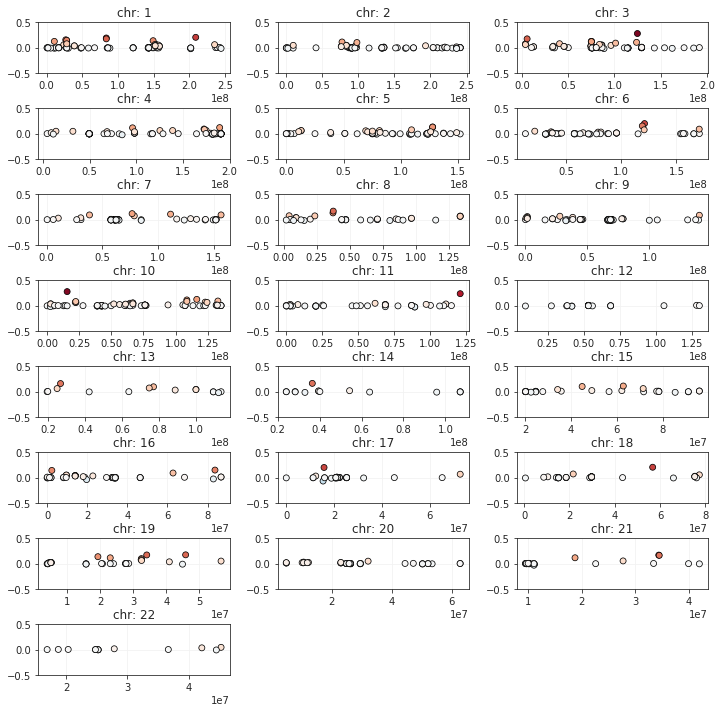

In [21]:
fig = plt.figure(figsize=(12,12))
plt.subplots_adjust(hspace=0.7, wspace=0.25)
for i in range(22):
    ax1=plt.subplot(8, 3, i+1)
    plt.title(f"chr: {i+1}")
    sns.scatterplot(x='pos', y="X50_mean", data=feat_imp_train[feat_imp_train["chr"]==i+1], hue="X50_mean", hue_norm=(-0.3,0.3), palette="RdBu_r", edgecolor="k")
    ax1.get_legend().remove()
    plt.ylim(-0.5,0.5)
    plt.ylabel("")
    plt.xlabel("")


In [22]:
selection = feat_imp_train[abs(feat_imp_train['X50_mean'])> 0.05]

In [23]:
selection.sort_values(by='X50_mean').to_csv("feature_importance.csv")

In [24]:
selection.sort_values(by='X50_mean', ascending=False).head(100)

,X50_mean,X50_median,chr,pos
snp_3_124845764,0.281739,0.304566,3,124845764.0
snp_10_15653813,0.277959,0.309476,10,15653813.0
snp_11_120855337,0.237023,0.257174,11,120855337.0
snp_1_209147965,0.206318,0.246766,1,209147965.0
snp_18_56742728,0.204727,0.228291,18,56742728.0
...,...,...,...,...
snp_5_69380555,0.058056,0.054817,5,69380555.0
snp_5_13011775,0.057930,0.044733,5,13011775.0
snp_10_66737523,0.055357,0.042903,10,66737523.0
snp_3_86458621,0.055046,0.050851,3,86458621.0


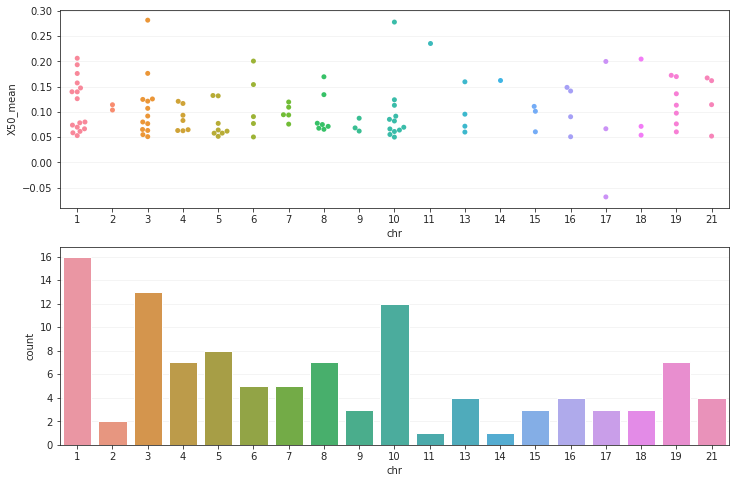

In [25]:
fig = plt.figure(figsize=(12,8))
plt.subplot(211)
# sns.stripplot(x="chr", y="X50_mean", data=selection, jitter=0.15)
sns.swarmplot(x="chr", y="X50_mean", data=selection)
plt.subplot(212)
# sns.barplot(x="chr", y="X50_mean", data=selection)
sns.countplot(x="chr", data=selection)

## Análise por sexo

In [66]:
# feature importance - M x F
# age: 50, set: test

In [26]:
feat_imp_M50 = feat_importance(e_train, 50, 'M', samples_per_model=1)
feat_imp_F50 = feat_importance(e_train, 50, 'F', samples_per_model=1)

In [27]:
tmp = feat_imp_M50.join(feat_imp_F50, how='inner')
tmp

,M50_mean,M50_median,F50_mean,F50_median
snp_8_133462953,0.070271,1.896545e-03,0.072106,0.002156
snp_2_91635413,0.003407,2.380562e-04,0.003937,0.000423
snp_9_25963828,0.000233,8.873147e-08,0.000489,0.000008
snp_1_17764169,0.003327,7.524572e-04,0.003669,0.000808
snp_12_41767967,-0.007176,-3.434144e-03,-0.007151,-0.003264
...,...,...,...,...
snp_20_26104019,0.003127,8.592351e-04,0.003149,0.000887
snp_20_50189624,-0.006103,-4.765265e-03,-0.006220,-0.004860
snp_1_143276644,-0.000414,1.190563e-05,-0.000561,0.000001
snp_16_9536673,0.002110,-2.150678e-05,0.001701,-0.000028


In [28]:
tmp.sort_values(by="M50_mean").to_csv("feature_importance_sex.csv")

(-0.2, 0.35)

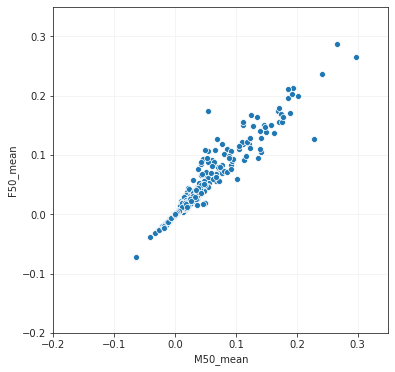

In [29]:
fig = plt.figure(figsize=(6,6))
sns.scatterplot(x="M50_mean", y="F50_mean", data=tmp)
plt.ylim(-0.2,0.35)
plt.xlim(-0.2,0.35)

(-0.2, 0.35)

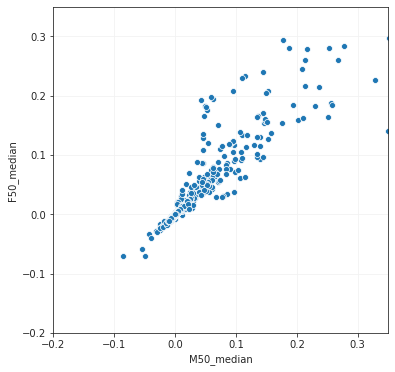

In [71]:
fig = plt.figure(figsize=(6,6))
sns.scatterplot(x="M50_median", y="F50_median", data=tmp)
plt.ylim(-0.2,0.35)
plt.xlim(-0.2,0.35)

In [72]:
tmp.sort_values(by="F50_mean").tail(20)

,M50_mean,M50_median,F50_mean,F50_median
snp_6_121073528,0.300913,0.328987,0.234240,0.225822
snp_1_26921907,0.173091,0.144791,0.235172,0.240708
snp_6_170653258,0.122207,0.114956,0.241994,0.232858
snp_1_83758875,0.213179,0.212803,0.245113,0.259871
snp_3_5574766,0.257845,0.235748,0.247065,0.214811
snp_21_34506464,0.275438,0.267410,0.255078,0.260911
snp_8_37417160,0.272273,0.278258,0.275880,0.283820
snp_4_189363499,0.186699,0.186430,0.280947,0.280411
snp_19_19365233,0.215043,0.217101,0.282580,0.278981
snp_13_26574243,0.183778,0.176969,0.292195,0.294581


In [73]:
tmp = feat_imp_M50.join(feat_imp_F50, how='inner')
tmp = tmp[abs((tmp['M50_mean']+tmp['F50_mean']))/2 > 0.05]
tmp['SNP'] = tmp.index
# parallel_coordinates(tmp, '1_M50', cols='M50_mean','F50_mean'])
tmp.sort_values(by="M50_mean")

,M50_mean,M50_median,F50_mean,F50_median,SNP
snp_16_19717582,-0.090055,-0.085423,-0.086209,-0.070731,snp_16_19717582
snp_17_15464147,-0.064083,-0.054242,-0.075300,-0.058970,snp_17_15464147
snp_8_80259779,-0.052823,-0.049127,-0.067340,-0.071049,snp_8_80259779
snp_15_34163723,0.031508,0.023261,0.073001,0.070231,snp_15_34163723
snp_3_3745392,0.045297,0.046139,0.122484,0.107724,snp_3_3745392
...,...,...,...,...,...
snp_19_45860157,0.344706,0.363094,0.391005,0.386306,snp_19_45860157
snp_21_34424410,0.345585,0.350333,0.153828,0.140211,snp_21_34424410
snp_11_120855337,0.353854,0.352011,0.372990,0.296716,snp_11_120855337
snp_14_36490375,0.405674,0.383243,0.324506,0.326567,snp_14_36490375


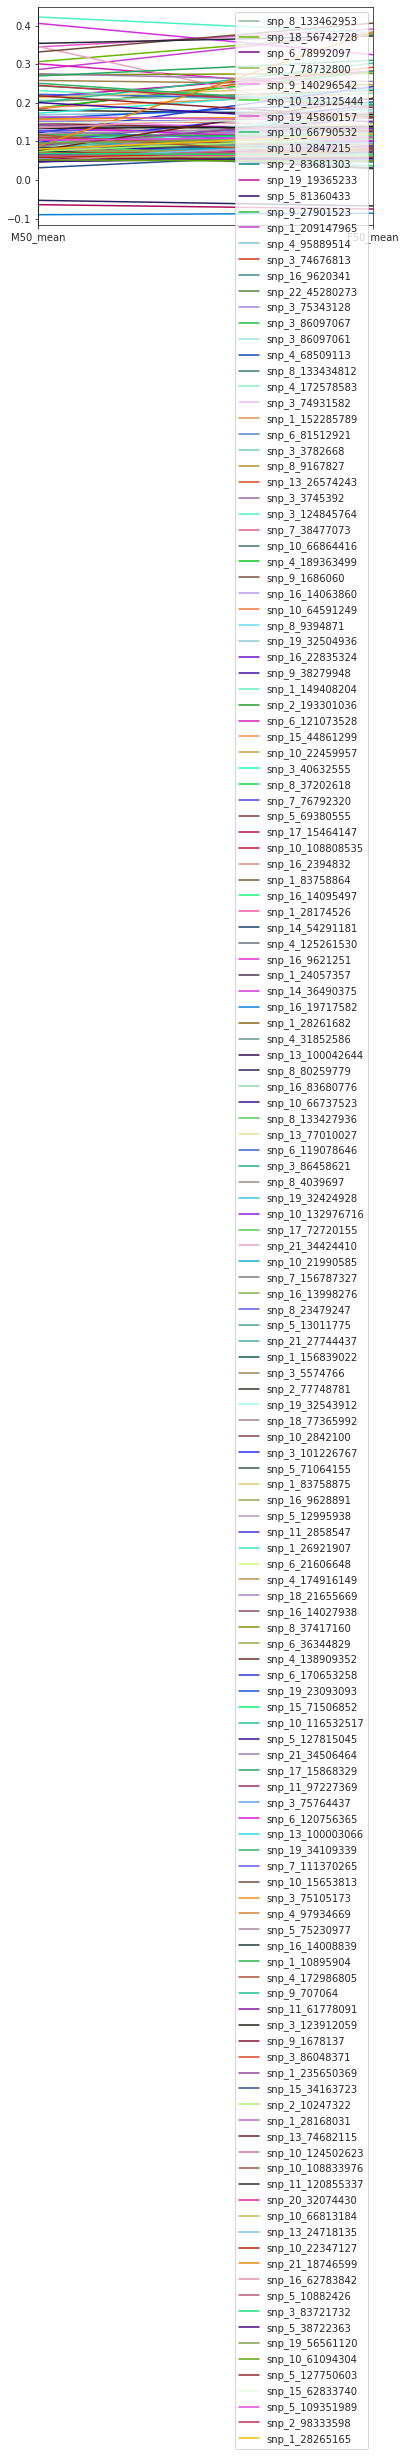

In [74]:
parallel_coordinates(tmp, 'SNP', cols=['M50_mean', 'F50_mean'])

In [75]:
# feature importance - lifelong variability

In [76]:
feat_imp_by_age = feat_importance(e_test, 20, 'X', samples_per_model=1) 
for age in range(30, 90, 10):
    feat_imp_by_age = feat_imp_by_age.join(feat_importance(e_test, age, 'X', samples_per_model=1),how='inner')

/home/jgcarvalho/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


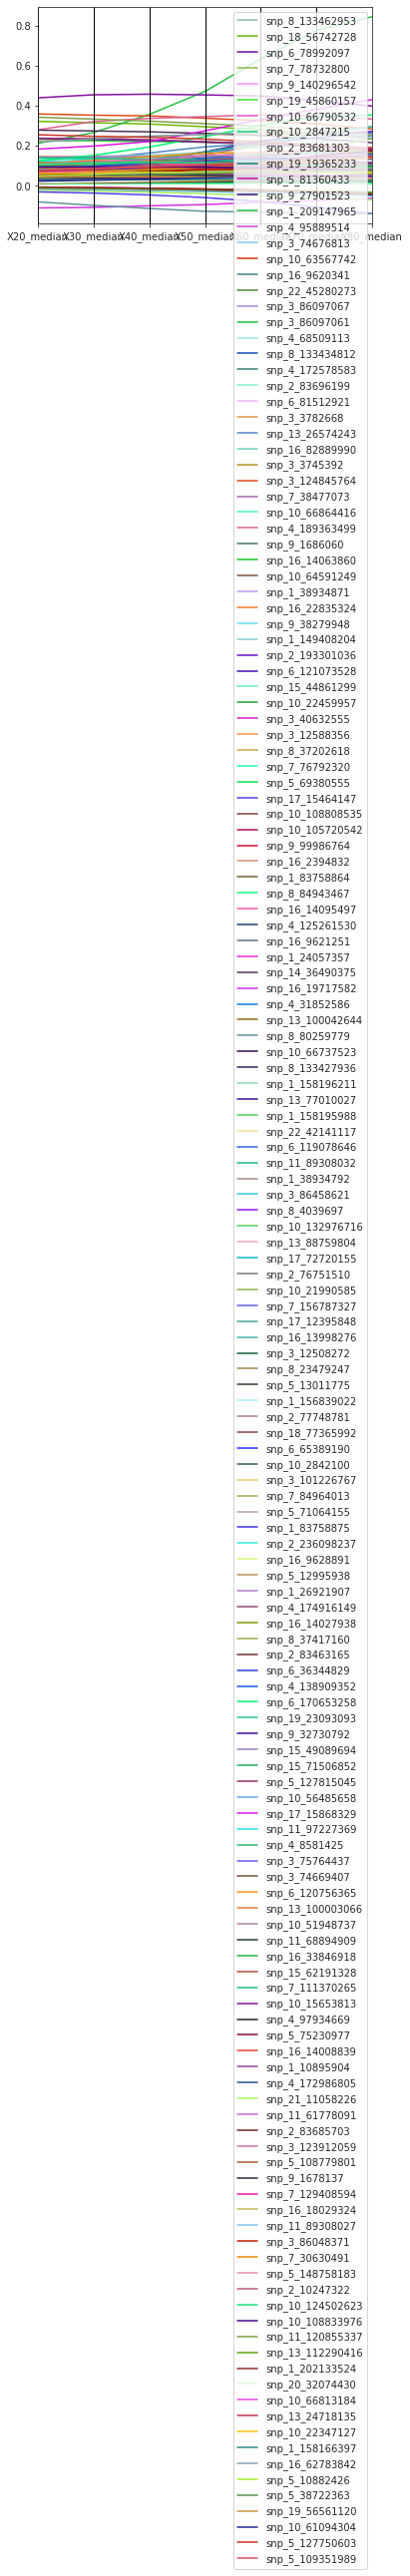

In [77]:
tmp = feat_imp_by_age[abs(feat_imp_by_age['X80_mean']) > 0.04]
tmp['SNP'] = tmp.index
parallel_coordinates(tmp, 'SNP', cols=[i for i in feat_imp_by_age.columns if 'median' in i])

In [78]:
tmp = feat_imp_M50.join(feat_imp_F50, how='inner')
tmp = tmp[abs((tmp['M50_mean']+tmp['F50_mean']))/2 > 0.04]
tmp['SNP'] = tmp.index
# parallel_coordinates(tmp, '1_M50', cols='M50_mean','F50_mean'])
tmp.sort_values(by="M50_mean")

,M50_mean,M50_median,F50_mean,F50_median,SNP
snp_16_19717582,-0.090055,-0.085423,-0.086209,-0.070731,snp_16_19717582
snp_17_15464147,-0.064083,-0.054242,-0.075300,-0.058970,snp_17_15464147
snp_8_80259779,-0.052823,-0.049127,-0.067340,-0.071049,snp_8_80259779
snp_9_32730792,-0.048665,-0.042461,-0.043790,-0.033785,snp_9_32730792
snp_21_11058226,-0.048183,-0.040044,-0.047184,-0.039192,snp_21_11058226
...,...,...,...,...,...
snp_19_45860157,0.344706,0.363094,0.391005,0.386306,snp_19_45860157
snp_21_34424410,0.345585,0.350333,0.153828,0.140211,snp_21_34424410
snp_11_120855337,0.353854,0.352011,0.372990,0.296716,snp_11_120855337
snp_14_36490375,0.405674,0.383243,0.324506,0.326567,snp_14_36490375


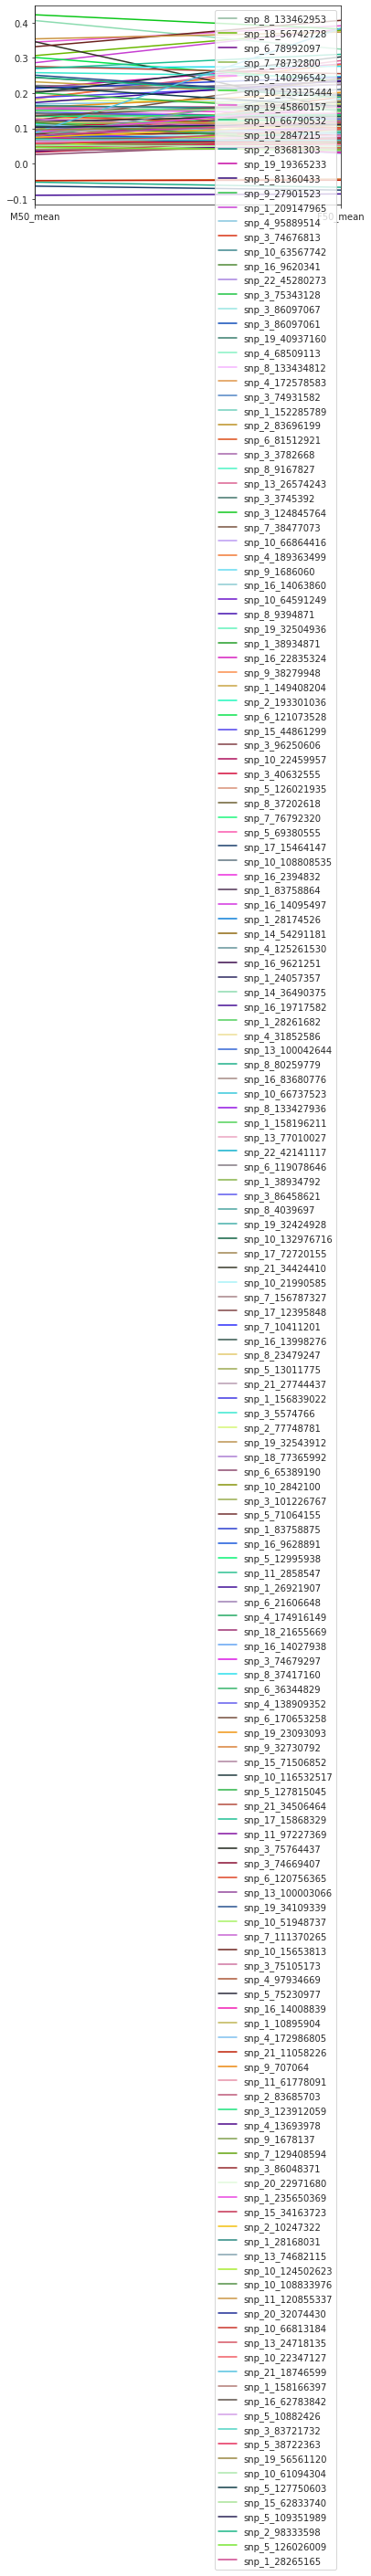

In [79]:
parallel_coordinates(tmp, 'SNP', cols=['M50_mean', 'F50_mean'])

In [80]:
feat_imp_by_age = feat_importance(e_test, 20, 'X', samples_per_model=1) 
for age in range(30, 90, 10):
    feat_imp_by_age = feat_imp_by_age.join(feat_importance(e_test, age, 'X', samples_per_model=1),how='inner')
    

KeyboardInterrupt: 

In [ ]:
[i for i in feat_imp_by_age.columns if 'mean' in i]

In [ ]:
tmp = feat_imp_by_age[abs(feat_imp_by_age['X80_mean']) > 0.04]
tmp['SNP'] = tmp.index
parallel_coordinates(tmp, 'SNP', cols=[i for i in feat_imp_by_age.columns if 'mean' in i])

In [ ]:
feat_imp_by_age[['X90_mean']].boxplot()

In [ ]:
feat_imp_M50.sort_values(by=0, ascending=False).head(50)

In [ ]:
imp = e_test.calc_attr(20, 'X', samples_per_model=1)

In [ ]:
s

In [ ]:
dfnew.sort_values(by=0, ascending=True).head(50)

In [ ]:
import pandas as pd
dfnew = pd.DataFrame.from_dict(s, orient='index')
dfnew.sort_values(by=0, ascending=False).head(50)

In [ ]:
import pandas as pd
dfnew = pd.DataFrame.from_dict(s, orient='index')
dfnew.sort_values(by=0, ascending=False).head(50)

In [ ]:
import pandas as pd
df = pd.DataFrame.from_dict(s, orient='index')

In [ ]:
df.sort_values(by=0, ascending=True).head(50)

In [ ]:
df.sort_values(by=0, ascending=True).head(50)

In [ ]:
import numpy as np
np.mean(df.values, axis=0)

In [ ]:
df_20_X = e_train.attr_snps_mean(attrs, mask).rename(columns={0: "age=20,sex=X"})

In [ ]:
df_20_X.sort_values(by="age=20,sex=X", ascending=False).head(50)

In [ ]:
attr, mask = e_train.calc_attr(20, 'X', samples=1)
df_20_X = e_train.attr_snps_mean(attr, mask).rename(columns={0: "age=20,sex=X"})
attr, mask = e_train.calc_attr(20, 'M', samples=1)
df_20_M = e_train.attr_snps_mean(attr, mask).rename(columns={0: "age=20,sex=M"})
attr, mask = e_train.calc_attr(20, 'F', samples=1)
df_20_F = e_train.attr_snps_mean(attr, mask).rename(columns={0: "age=20,sex=F"})

In [ ]:
df_decay2 = df_20_X.sort_values(by="age=20,sex=X", ascending=False)
df_decay2.head(20)

In [ ]:
df_decay1 = df_20_X.sort_values(by="age=20,sex=X", ascending=False)
df_decay1.head(20)

In [ ]:
df_train[df_train.index=='snp_4_172986805']

In [ ]:
attr, mask = e_train.calc_attr(50, 'X', samples=1)
df_50_X = e_train.attr_snps_mean(attr, mask).rename(columns={0: "age=50,sex=X"})
attr, mask = e_train.calc_attr(50, 'M', samples=1)
df_50_M = e_train.attr_snps_mean(attr, mask).rename(columns={0: "age=50,sex=M"})
attr, mask = e_train.calc_attr(50, 'F', samples=1)
df_50_F = e_train.attr_snps_mean(attr, mask).rename(columns={0: "age=50,sex=F"})

In [ ]:
df_train = df_20_X.join([df_20_F,df_20_M,df_50_X,df_50_F,df_50_M])

In [ ]:
df_train.sort_values(by="age=20,sex=X", ascending=False).head(50)

In [ ]:
df_train.sort_values(by="age=50,sex=X", ascending=False).tail(50)

In [ ]:
plt.boxplot(df_20_X.values)

In [ ]:
attr, mask = e_test.calc_attr(20, 'X', samples=1)
df_20_X_test = e_test.attr_snps_mean(attr, mask).rename(columns={0: "age=20,sex=X"})
attr, mask = e_test.calc_attr(20, 'M', samples=1)
df_20_M_test = e_test.attr_snps_mean(attr, mask).rename(columns={0: "age=20,sex=M"})
attr, mask = e_test.calc_attr(20, 'F', samples=1)
df_20_F_test = e_test.attr_snps_mean(attr, mask).rename(columns={0: "age=20,sex=F"})

In [ ]:
attr, mask = e_test.calc_attr(50, 'X', samples=1)
df_50_X_test = e_test.attr_snps_mean(attr, mask).rename(columns={0: "age=50,sex=X"})
attr, mask = e_test.calc_attr(50, 'M', samples=1)
df_50_M_test = e_test.attr_snps_mean(attr, mask).rename(columns={0: "age=50,sex=M"})
attr, mask = e_test.calc_attr(50, 'F', samples=1)
df_50_F_test = e_test.attr_snps_mean(attr, mask).rename(columns={0: "age=50,sex=F"})

In [ ]:
df_test = df_20_X_test.join([df_20_F_test,df_20_M_test,df_50_X_test,df_50_F_test,df_50_M_test])

In [ ]:
df_test.sort_values(by="age=20,sex=X", ascending=False).head(50)

In [ ]:
df_test.sort_values(by="age=20,sex=X", ascending=False).tail(50)

In [ ]:
df = df_train.join(df_test, lsuffix='_train', rsuffix='_test')

In [ ]:
sns.pairplot(df.sort_values(by="age=20,sex=X_train", ascending=False).head(20))
# plt.savefig('pairplot.svg')

In [ ]:
df.sort_values(by="age=20,sex=X_train", ascending=False).head(20)

In [ ]:
df_sel = df.reindex(df["age=20,sex=X_train"].abs().sort_values(ascending=False).index).head(100)

In [ ]:
df_sel

In [ ]:
tmp = dict(Counter([s[:s.index('_',4)] for s in list(df_sel.index)]))
sns.barplot(x=list(tmp.keys()), y=list(tmp.values()))

In [ ]:
df_not_sel = df.reindex(df["age=20,sex=X_train"].abs().sort_values(ascending=False).index).tail(500)

In [ ]:
Counter([s[:s.index('_',4)] for s in list(df_not_sel.index)])

In [ ]:
list(tmp.values())

In [ ]:
plt.subplot(141)
plt.title("Precision")
plt.barh(y=list(tmp.keys()),width=list(tmp.values()))
# plt.xlim(0,1)
plt.subplot(142)
plt.title("Recall")
plt.barh(y=list(tmp.keys()),width=list(tmp.values()))
# plt.xlim(0,1)
plt.yticks([])
plt.subplot(143)
plt.title("F1-Score")
plt.barh(y=list(tmp.keys()),width=list(tmp.values()))
# plt.xlim(0,1)
plt.yticks([])
plt.subplot(144)
plt.title("Frequency")
plt.barh(y=list(tmp.keys()),width=list(tmp.values()))
plt.xscale('log')
plt.yticks([])

In [ ]:
feat_imp_M50.sort_values(by='M50_mean')

In [ ]:
feat_imp_M50.sort_values(by='M50_mean')

In [ ]:
plt.boxplot(feat_imp_M50['M50_mean'])

In [ ]:
df_test = pd.read_csv("../datasets/visits_sp_unique_test_positivo_1000_random_0.csv")

In [ ]:
df_train = pd.read_csv("../datasets/visits_sp_unique_train_positivo_1000_random_0.csv")

In [ ]:
c1 = df_test.columns
c2 = df_train.columns
for i in range(1009):
    if c1[i] != c2[i]:
        print(f"{c1[i]} = {c2[i]}")
    

In [ ]:
a = np.arange(-10,10)

In [ ]:
a

In [ ]:
plt.scatter(x=1,y=a)